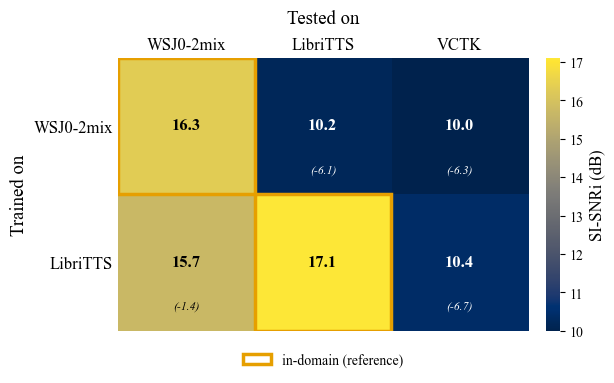

In [5]:
"""
ecological_validity_figures.py
Two templates for the thesis "ecological validity" argument:

  (A) plot_generalization_matrix() : train x test heatmap of SI-SDRi.
      The asymmetry across the diagonal (train-on-WSJ0 -> drops a lot;
      train-on-real -> WSJ0 almost for free) is the headline.

  (B) plot_rank_reversal() : leaderboard re-ordering between a clean
      benchmark (WSJ0) and an ecological set. Crossing lines = the
      benchmark misranks methods.

All numbers below are ILLUSTRATIVE placeholders — replace with your results.
Requires: matplotlib (numpy optional).
"""
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---- shared style: Times New Roman + Okabe-Ito colourblind-safe accents ----
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "Tinos", "DejaVu Serif"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})
ORANGE, BLUE, VERM, GREEN, GREY = "#E69F00", "#0072B2", "#D55E00", "#009E73", "#9aa0a6"


# ===========================================================================
# (A) Train x Test generalisation matrix
# ===========================================================================
def plot_generalization_matrix(values, train_labels, test_labels,
                               cmap="cividis", save_prefix=None):
    """
    values        : 2D list/array [n_train][n_test] of SI-SDRi (dB)
    train_labels  : row labels (training corpus)
    test_labels   : column labels (evaluation corpus)
    Diagonal (train==test by label) is outlined as the in-domain reference.
    """
    nr, nc = len(values), len(values[0])
    vmin = min(v for row in values for v in row)
    vmax = max(v for row in values for v in row)

    fig, ax = plt.subplots(figsize=(1.35 * nc + 2.2, 1.0 * nr + 2.0))
    im = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    # annotate each cell; pick black/white text for contrast
    for i in range(nr):
        for j in range(nc):
            frac = (values[i][j] - vmin) / (vmax - vmin + 1e-9)
            ax.text(j, i, f"{values[i][j]:.1f}", ha="center", va="center",
                    color="black" if frac > 0.55 else "white",
                    fontsize=12, fontweight="bold")
            # mark cross-domain drop relative to that row's in-domain cell
            if train_labels[i] in test_labels:
                d = test_labels.index(train_labels[i])
                drop = values[i][j] - values[i][d]
                if j != d:
                    ax.text(j, i + 0.32, f"({drop:+.1f})", ha="center", va="center",
                            color="black" if frac > 0.55 else "white",
                            fontsize=8.5, style="italic")

    # outline in-domain (diagonal) cells
    for i in range(nr):
        if train_labels[i] in test_labels:
            j = test_labels.index(train_labels[i])
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                   edgecolor=ORANGE, linewidth=2.5, zorder=3))

    ax.set_xticks(range(nc)); ax.set_xticklabels(test_labels, fontsize=12)
    ax.set_yticks(range(nr)); ax.set_yticklabels(train_labels, fontsize=12)
    ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
    ax.set_xlabel("Tested on", fontsize=13.5, labelpad=10)
    ax.set_ylabel("Trained on", fontsize=13.5)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("SI-SNRi (dB)", fontsize=12)
    cb.outline.set_visible(False)
    # legend note for the diagonal outline
    ax.add_patch(Rectangle((0, 0), 0, 0, fill=False, edgecolor=ORANGE,
                           linewidth=2.5, label="in-domain (reference)"))
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), frameon=False,
              fontsize=10)

    fig.tight_layout()
    if save_prefix:
        for ext in ("pdf", "svg", "png"):
            fig.savefig(f"{save_prefix}.{ext}", bbox_inches="tight", dpi=200)
    return fig, ax


# ===========================================================================
# (B) Rank-reversal between a clean benchmark and an ecological set
# ===========================================================================
def _ranks(scores):                      # 1 = best (highest score)
    order = sorted(range(len(scores)), key=lambda i: -scores[i])
    r = [0] * len(scores)
    for pos, i in enumerate(order):
        r[i] = pos + 1
    return r


def _spearman(a, b):
    ra, rb = _ranks([-x for x in a]), _ranks([-x for x in b])  # ascending ranks
    n = len(a)
    d2 = sum((ra[i] - rb[i]) ** 2 for i in range(n))
    return 1 - 6 * d2 / (n * (n * n - 1))


def plot_rank_reversal(models, score_clean, score_eco,
                       clean_name="WSJ0-2mix", eco_name="Ecological set",
                       save_prefix=None):
    """
    models       : list of model names
    score_clean  : their SI-SDRi on the clean benchmark
    score_eco    : their SI-SDRi on the ecological set
    Lines connect each model's rank on the two benchmarks; crossings = reshuffle.
    """
    n = len(models)
    rc, re = _ranks(score_clean), _ranks(score_eco)
    rho = _spearman(score_clean, score_eco)

    fig, ax = plt.subplots(figsize=(6.4, 0.55 * n + 1.8))
    for i, m in enumerate(models):
        moved = rc[i] != re[i]
        col = VERM if (re[i] - rc[i]) > 0 else (GREEN if (re[i] - rc[i]) < 0 else GREY)
        ax.plot([0, 1], [rc[i], re[i]], "-", color=col if moved else GREY,
                lw=2.2 if moved else 1.4, alpha=0.9, zorder=2)
        ax.scatter([0, 1], [rc[i], re[i]], s=42, color=col if moved else GREY, zorder=3)
        ax.text(-0.04, rc[i], f"{m}  ({score_clean[i]:.1f})", ha="right", va="center", fontsize=10)
        ax.text(1.04, re[i], f"({score_eco[i]:.1f})  {m}", ha="left", va="center", fontsize=10)

    ax.set_xlim(-0.55, 1.55); ax.set_ylim(n + 0.5, 0.5)   # rank 1 at top
    ax.set_xticks([0, 1]); ax.set_xticklabels([clean_name, eco_name], fontsize=12.5)
    ax.set_yticks(range(1, n + 1)); ax.set_ylabel("Rank", fontsize=12.5)
    ax.tick_params(length=0)
    for s in ("top", "right", "bottom"):
        ax.spines[s].set_visible(False)
    ax.set_title(f"Leaderboard re-ordering   (Spearman $\\rho$ = {rho:.2f})",
                 fontsize=12.5, pad=12)
    fig.tight_layout()
    if save_prefix:
        for ext in ("pdf", "svg", "png"):
            fig.savefig(f"{save_prefix}.{ext}", bbox_inches="tight", dpi=200)
    return fig, ax


# ===========================================================================
if __name__ == "__main__":
    # ---- (A) placeholder matrix: 2 training sets x 3 test sets (Kadioglu et al. 2020, Fig 5) ----
    # Only WSJ0- and LibriTTS-trained models exist; VCTK is eval-only (held-out),
    # so its column has no in-domain reference cell -- that is the point.
    train_labels = ["WSJ0-2mix", "LibriTTS"]
    test_labels  = ["WSJ0-2mix", "LibriTTS", "VCTK"]
    values = [   # SI-SDRi (dB) — illustrative, matching the paper's average drops
        [16.3,  10.2,  10.0],   # WSJ0-trained:    -6.2 / -6.3 off-domain (collapses)
        [15.7, 17.1,  10.4],   # LibriTTS-trained: -1.7 on WSJ0 (nearly free), -7.3 on VCTK
    ]
    plot_generalization_matrix(values, train_labels, test_labels,
                               save_prefix="xdataset_matrix")

    plt.show()